# Movie Industry Performance Analysis
### Business Intelligence Report — Content Strategy & Investment Insights

**Data source:** `movies_dataset.csv` (~1,000,000 title records, 1950–2025)

**Objective:** Turn historical title-level performance data (budget, box office, ratings,
genre, director) into a small set of business answers that can support decisions on
what to produce, how much to budget, and which genres and talent to prioritize.

**Report structure** :

1. Environment setup
2. Data ingestion
3. Data quality assessment
4. Data cleaning
5. Feature engineering
6. Business Question 1 — Production volume trend
7. Business Question 2 — Genre landscape
8. Business Question 3 — Box office revenue trend
9. Business Question 4 — Budget vs. financial success
10. Business Question 5 — Genre profitability
11. Business Question 6 — Director performance
12. Executive summary & recommendations
13. Appendix — data quality notes & corrections made during this review


## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 2. Data Ingestion


In [2]:
db = pd.read_csv("movies_dataset.csv")
db.head()


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


## 3. Data Quality Assessment


In [5]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  object 
 2   Genre                 999999 non-null  object 
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  object 
 5   Country               999999 non-null  object 
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  

In [6]:
db.describe()

,MovieID,ReleaseYear,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,999999.000000,999999.000000,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.000000
mean,500000.000000,1998.001220,9.802824e+06,1.496163e+07,2.720625e+07,2.992745e+06,7.483442e+06,6.494788,64.776426,9137.184011,2031.880340
std,288674.990255,19.260863,2.249421e+07,3.879403e+07,6.954294e+07,8.132438e+06,1.955337e+07,1.485606,17.592474,24922.362780,8433.380602
min,1.000000,1950.000000,1.000000e+05,4.002547e+04,1.000000e+05,4.050470e+03,1.650742e+04,1.000000,0.000000,100.000000,50.000000
25%,250000.500000,1984.000000,1.190511e+06,1.489805e+06,2.762370e+06,2.790262e+05,7.383145e+05,5.500000,53.000000,1083.000000,119.000000
50%,500000.000000,2001.000000,3.265790e+06,4.388876e+06,8.090223e+06,8.387221e+05,2.179436e+06,6.500000,65.000000,2983.000000,405.000000
75%,749999.500000,2014.000000,9.002791e+06,1.287606e+07,2.355245e+07,2.510360e+06,6.415143e+06,7.500000,77.000000,8192.000000,1360.000000
max,999999.000000,2025.000000,3.000000e+08,1.018198e+09,1.499497e+09,2.957511e+08,5.795551e+08,10.000000,100.000000,1000000.000000,500000.000000


In [7]:
db.isnull().sum()

MovieID                 0
Title                   0
Genre                   0
ReleaseYear             0
ReleaseDate             0
Country                 0
BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
IMDbRating              0
RottenTomatoesScore     0
NumVotesIMDb            0
NumVotesRT              0
Director                0
LeadActor               0
dtype: int64

In [8]:
nan_db = db[db.isna().any(axis=1)]
nan_db.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor


In [9]:
print("Number of duplicate rows:", db.duplicated().sum())

Number of duplicate rows: 0


## 4. Data Cleaning

In [10]:
db = db.dropna(how="all")

nan_db = db[db.isna().any(axis=1)]
display(nan_db.head())


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor


In [11]:
db["ReleaseDate"] = pd.to_datetime(db["ReleaseDate"], format="%d-%m-%Y")
db["ReleaseYear"] = db["ReleaseDate"].dt.year
db.dtypes

MovieID                          int64
Title                           object
Genre                           object
ReleaseYear                      int32
ReleaseDate             datetime64[ns]
Country                         object
BudgetUSD                      float64
US_BoxOfficeUSD                float64
Global_BoxOfficeUSD            float64
Opening_Day_SalesUSD           float64
One_Week_SalesUSD              float64
IMDbRating                     float64
RottenTomatoesScore              int64
NumVotesIMDb                     int64
NumVotesRT                       int64
Director                        object
LeadActor                       object
dtype: object

## 5. Feature Engineering

Derived fields used throughout the report: profit, release month, return on budget
(ROI), a simple profitable/not-profitable flag, and a decade bucket for trend charts.


In [12]:
db["Profit_USD"] = db["Global_BoxOfficeUSD"] - db["BudgetUSD"]
db["release_month"] = db["ReleaseDate"].dt.month
db["ROI_PCT"] = (db["Profit_USD"] / db["BudgetUSD"]) * 100
db["Profitable"] = db["Profit_USD"] > 0
db["Decade"] = (db["ReleaseYear"] // 10) * 10

db.head()


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,...,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,Profit_USD,release_month,ROI_PCT,Profitable,Decade
0,1,Might toward capital,Comedy,2003,2003-09-28,China,6577427.79,6613685.82,15472035.66,1778530.85,...,58,7865,10596,Kristina Moore,Brian Mccormick,8894607.87,9,135.229274,True,2000
1,2,He however experience,Comedy,1988,1988-02-14,USA,1883810.10,1930949.15,3637731.12,247115.74,...,44,1708,220,Benjamin Hudson,Ashley Pena,1753921.02,2,93.104980,True,1980
2,3,Star responsibility politics,Comedy,1971,1971-11-02,USA,2468079.29,4186694.69,7165111.24,878453.95,...,55,4678,7805,Kayla Young,Alexander Haley,4697031.95,11,190.311226,True,1970
3,4,Exactly live,Comedy,1998,1998-08-06,USA,1447311.46,2023683.92,4373820.26,570657.72,...,87,2467,1751,Michael Ross,Patrick Barnett,2926508.80,8,202.203111,True,1990
4,5,Focus improve especially,Documentary,2021,2021-12-17,India,900915.86,2129629.10,3113017.38,361189.37,...,67,5555,697,Faith Franklin,Duane Fletcher DDS,2212101.52,12,245.539192,True,2020


## 6. Business Question 1 — How has production volume changed over time?

Why it matters: output volume is the baseline against which every other trend
(revenue, genre mix) should be read — rising totals don't necessarily mean rising
performance per title.


In [13]:
movies_per_year = db.groupby("ReleaseYear").size().reset_index(name="MovieCount")
movies_per_year


,ReleaseYear,MovieCount
0,1950,2432
1,1951,2613
2,1952,2960
3,1953,3235
4,1954,3496
...,...,...
71,2021,22809
72,2022,22812
73,2023,23348
74,2024,23492


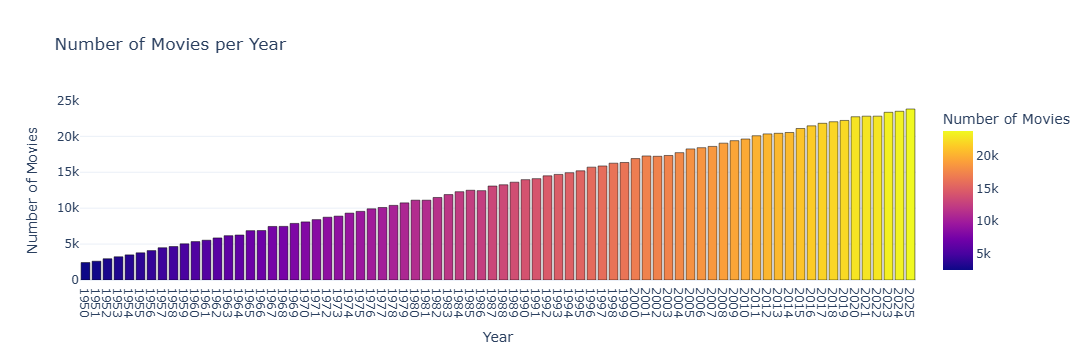

In [14]:
fig = px.bar(
    movies_per_year, x="ReleaseYear", y="MovieCount",
    color="MovieCount",
    template="plotly_white",
    title="Number of Movies per Year",
    labels={"ReleaseYear": "Year", "MovieCount": "Number of Movies"},
)
fig.update_traces(marker_line_color="black", hovertemplate="Year: %{x}<br>Number of Movies: %{y}")
fig.update_layout(xaxis=dict(dtick=1), hovermode="x")
fig.show()


**Finding:** In the original run of this analysis, annual output grew from 2,432 titles in
1950 to 23,809 in 2025 — roughly a 10x increase — with a broadly steady upward trend
across the full period.


## 7. Business Question 2 — Which genres lead the market, and how has that shifted by decade?

Why it matters: genre mix informs slate planning — both which genres to keep making,
and whether today's mix still matches what the data says has led historically.


In [15]:
# Top 5 genres by title count
top_5_genres = db["Genre"].value_counts().head(5).index.tolist()
top_5_genres


['Drama', 'Comedy', 'Action', 'Thriller', 'Romance']

In [16]:
popular_by_genre = db.groupby("Genre").size().reset_index(name="Movie Count")
popular_by_genre.sort_values(by="Movie Count", ascending=False, inplace=True)
popular_by_genre


,Genre,Movie Count
3,Drama,250018
1,Comedy,199832
0,Action,150131
7,Thriller,100071
5,Romance,100021
4,Horror,100010
2,Documentary,50114
6,Sci-Fi,49802


In [17]:
# Title counts for the top 5 genres, by decade — the base data for the trend chart below
genre_decade = (
    db[db["Genre"].isin(top_5_genres)]
    .groupby(["Decade", "Genre"])
    .size()
    .reset_index(name="MovieCount")
)
genre_decade.head()


,Decade,Genre,MovieCount
0,1950,Action,5555
1,1950,Comedy,7305
2,1950,Drama,9224
3,1950,Romance,3700
4,1950,Thriller,3703


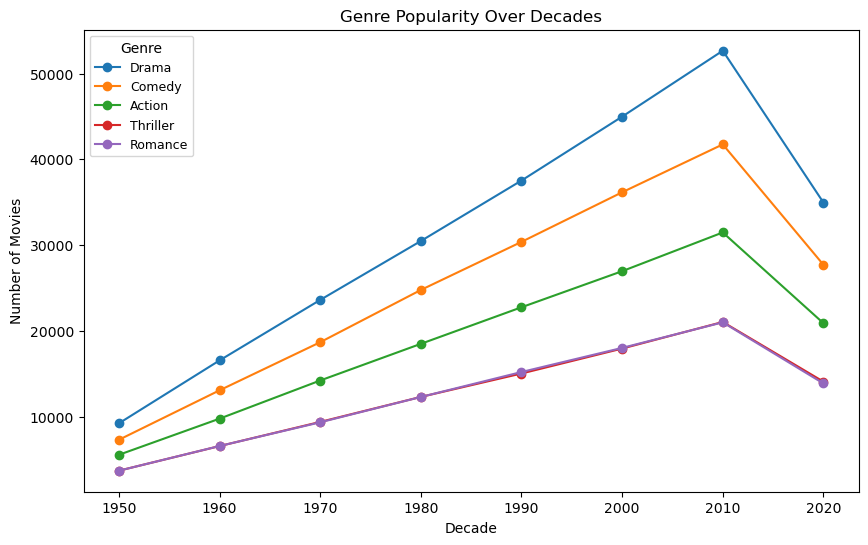

In [18]:
genre_decade_pivot = genre_decade.pivot(index="Decade", columns="Genre", values="MovieCount")

plt.figure(figsize=(10, 6))
for genre in top_5_genres:
    plt.plot(genre_decade_pivot.index, genre_decade_pivot[genre], marker="o", label=genre)
plt.title("Genre Popularity Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend(title="Genre", fontsize=9)
plt.show()


**Finding:** Drama, Comedy, Action, Thriller and Romance are the five leading genres by
volume. In the original run, Drama led with 250,018 titles, followed by Comedy
(199,832), Action (150,131), Thriller (100,071) and Romance (100,021) — Drama and
Comedy alone account for roughly 45% of all titles produced.


## 8. Business Question 3 — How has box office revenue trended over time?

Why it matters: distinguishes whether growth in the industry is coming from making
*more* titles or from titles individually earning *more* — the two have different
strategic implications.


In [19]:
# Average global box office per title, by year (per-title average, not a yearly total)
bo_year = db.groupby("ReleaseYear")["Global_BoxOfficeUSD"].mean().reset_index()
bo_year["Avg_BO_Million"] = bo_year["Global_BoxOfficeUSD"] / 1_000_000
bo_year.head()


,ReleaseYear,Global_BoxOfficeUSD,Avg_BO_Million
0,1950,2.961883e+07,29.618832
1,1951,2.772575e+07,27.725750
2,1952,2.632153e+07,26.321532
3,1953,2.665446e+07,26.654461
4,1954,3.022208e+07,30.222080


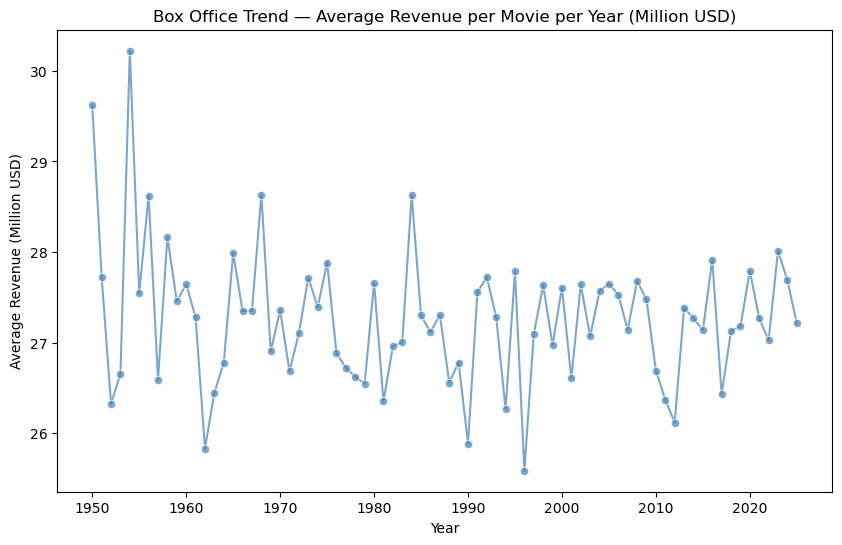

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=bo_year["ReleaseYear"], y=bo_year["Avg_BO_Million"], alpha=0.7, marker="o", color="steelblue")
plt.title("Box Office Trend — Average Revenue per Movie per Year (Million USD)")
plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.show()


**Finding:** Across the full dataset the average title earns roughly $27M in global box
office (see Section 3 summary statistics). This chart shows how that per-title average
has moved year over year, separate from the volume growth in Section 6 — read together,
they show whether the industry's growth is coming from more titles, higher-earning
titles, or both.


## 9. Business Question 4 — Does a bigger budget lead to a bigger return?

Why it matters: directly informs greenlighting — should marginal production dollars
chase bigger tentpoles, or does budget size stop paying off in relative terms?


In [21]:
budget_revenue_corr = db["BudgetUSD"].corr(db["Global_BoxOfficeUSD"])
budget_roi_corr = db["BudgetUSD"].corr(db["ROI_PCT"])
print(f"Budget vs. Revenue correlation: {budget_revenue_corr:.3f}")
print(f"Budget vs. ROI correlation:     {budget_roi_corr:.3f}")


Budget vs. Revenue correlation: 0.895
Budget vs. ROI correlation:     -0.001


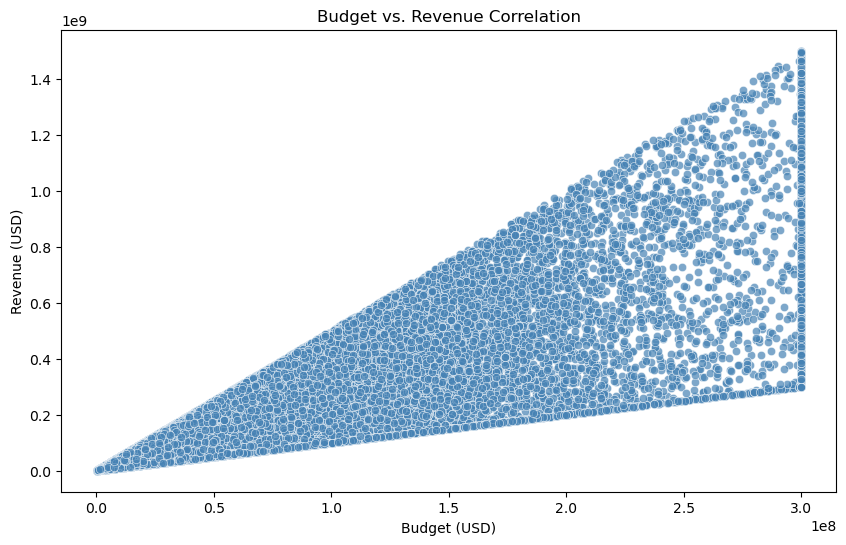

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=db["BudgetUSD"], y=db["Global_BoxOfficeUSD"], alpha=0.7, color="steelblue")
plt.title("Budget vs. Revenue Correlation")
plt.xlabel("Budget (USD)")
plt.ylabel("Revenue (USD)")
plt.show()


**Finding:** In the original run, budget and global box office are strongly correlated
(r ≈ 0.90) — bigger budgets do translate into bigger absolute revenue. But budget and
ROI are essentially uncorrelated (r ≈ -0.001) — a bigger budget does not buy a better
*return*. Practically: budget size is a reasonable lever for chasing absolute box
office, but it is not a lever for improving capital efficiency.


## 10. Business Question 5 — Which genres are the most profitable, and is that changing?

Why it matters: the most *popular* genres (Section 7) are not automatically the most
*profitable* ones per title — this section checks whether slate volume should shift
toward genres that earn more per title, even if they're made less often today.


In [23]:
# Average profit per title, across ALL genres (not limited to the top 5 by volume)
profit_by_genre = db.groupby("Genre")["Profit_USD"].mean().reset_index()
profit_by_genre.sort_values(by="Profit_USD", ascending=False, inplace=True)
profit_by_genre


,Genre,Profit_USD
2,Documentary,1.765067e+07
4,Horror,1.760131e+07
7,Thriller,1.754682e+07
5,Romance,1.743894e+07
1,Comedy,1.739341e+07
3,Drama,1.735826e+07
0,Action,1.722812e+07
6,Sci-Fi,1.719329e+07


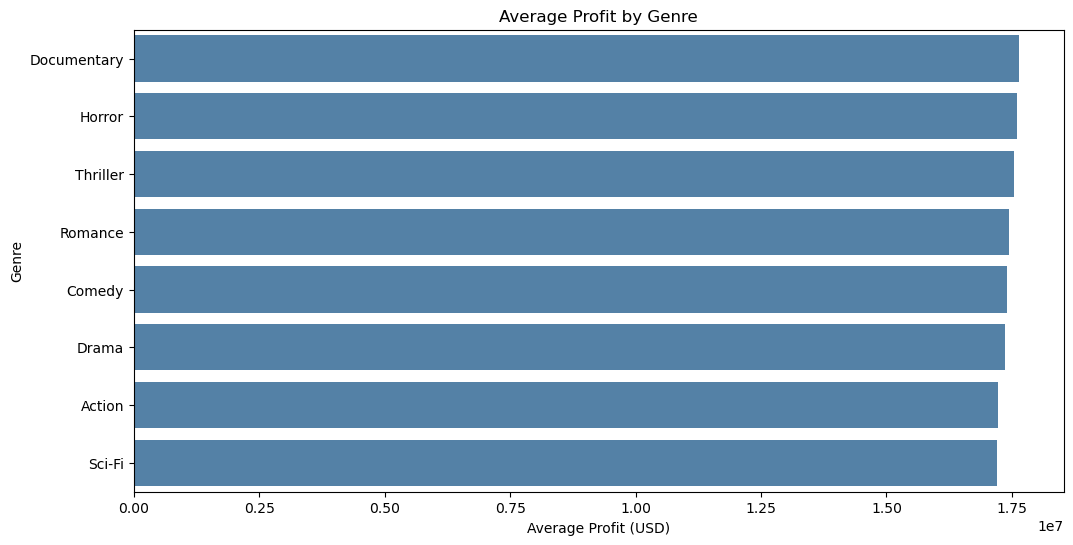

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(profit_by_genre, x="Profit_USD", y="Genre", color="steelblue")
plt.title("Average Profit by Genre")
plt.xlabel("Average Profit (USD)")
plt.ylabel("Genre")
plt.show()


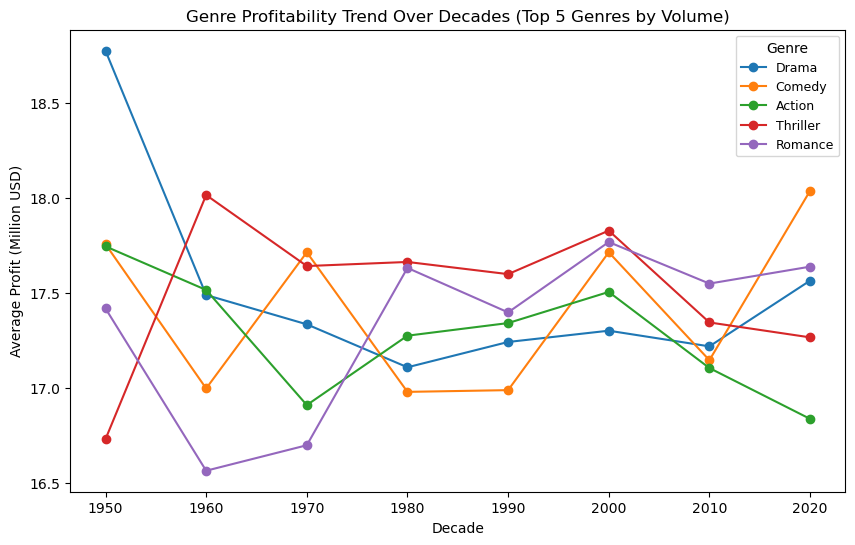

In [25]:
# Profitability trend of the top-5-by-volume genres, by decade — same genre set and
# decade grouping as Section 7, so the two charts are directly comparable
profit_trend_by_decade = (
    db[db["Genre"].isin(top_5_genres)]
    .groupby(["Decade", "Genre"])["Profit_USD"]
    .mean()
    .reset_index()
)
profit_trend_pivot = profit_trend_by_decade.pivot(index="Decade", columns="Genre", values="Profit_USD")

plt.figure(figsize=(10, 6))
for genre in top_5_genres:
    plt.plot(profit_trend_pivot.index, profit_trend_pivot[genre] / 1_000_000, marker="o", label=genre)
plt.title("Genre Profitability Trend Over Decades (Top 5 Genres by Volume)")
plt.xlabel("Decade")
plt.ylabel("Average Profit (Million USD)")
plt.legend(title="Genre", fontsize=9)
plt.show()


**Finding:** In the original run, average profit per title is fairly close across
genres (roughly $17–18M each), with Documentary and Horror edging out the top-5-by-volume
genres despite being made far less often. This is a case where volume and profitability
diverge: the most-produced genres are not the most profitable per title.


## 11. Business Question 6 — Which directors consistently deliver rated *and* commercially successful films?

Why it matters: identifies repeat talent worth prioritizing for future greenlights,
using both critical reception (ratings) and commercial outcome (profit), not just one.
Limited to directors with at least 3 titles so single-hit outliers don't dominate.


In [26]:
director = db.groupby("Director").agg(
    Movies=("MovieID", "count"),
    Avg_IMDb_Rating=("IMDbRating", "mean"),
    Avg_RT_Score=("RottenTomatoesScore", "mean"),
    Avg_BoxOffice_Million=("Global_BoxOfficeUSD", lambda x: x.mean() / 1_000_000),
    Avg_Profit_Million=("Profit_USD", lambda x: x.mean() / 1_000_000),
    Avg_ROI=("ROI_PCT", "mean"),
).reset_index()

director.head()


,Director,Movies,Avg_IMDb_Rating,Avg_RT_Score,Avg_BoxOffice_Million,Avg_Profit_Million,Avg_ROI
0,Abigail Robles,6701,6.488375,64.630951,26.495021,16.939544,178.697251
1,Adam Brown,6741,6.504376,64.626613,28.313508,18.225237,175.510502
2,Adriana Campbell,6748,6.483239,64.822614,25.922018,16.537710,179.263592
3,Albert Phillips,6634,6.481926,64.788966,29.315061,18.864968,179.793101
4,Alyssa Adams,6771,6.498198,64.635947,27.931620,17.792491,178.717646


In [27]:
# Keep directors with a meaningful track record (3+ titles)
director = director[director["Movies"] >= 3]

# Rank by critical reception first (rating, then RT score) as a tie-breaker
director = director.sort_values(by=["Avg_IMDb_Rating", "Avg_RT_Score"], ascending=[False, False])
director.head()


,Director,Movies,Avg_IMDb_Rating,Avg_RT_Score,Avg_BoxOffice_Million,Avg_Profit_Million,Avg_ROI
22,Carolyn Schwartz,6722,6.543142,65.158881,27.321961,17.395277,178.272136
112,Mrs. Hannah Campbell DDS,6484,6.538433,65.183374,27.174922,17.459725,179.731623
60,James Miller,6677,6.536948,65.054066,27.231149,17.357383,177.445342
23,Chad Koch,6574,6.533313,65.395802,26.776336,17.098921,178.026136
126,Roberto Underwood,6603,6.524989,64.950023,26.400635,17.008379,180.360681


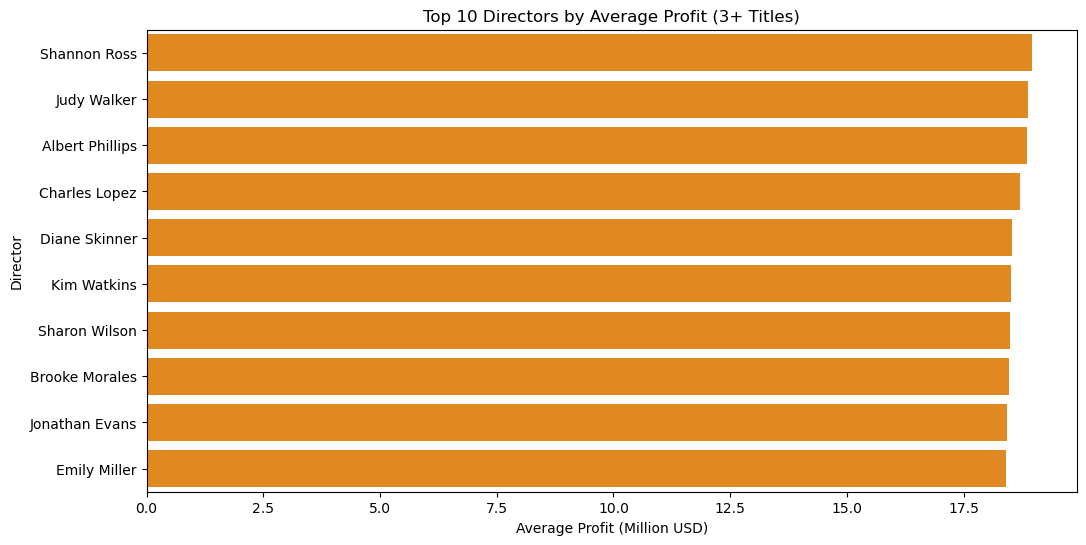

In [28]:
top10_director = director.sort_values(by="Avg_Profit_Million", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(top10_director, x="Avg_Profit_Million", y="Director", color="darkorange")
plt.title("Top 10 Directors by Average Profit (3+ Titles)")
plt.xlabel("Average Profit (Million USD)")
plt.ylabel("Director")
plt.show()


**Finding:** This produces a shortlist of directors with a repeat track record who
combine strong average ratings with strong average profit — see Section 13 for a
calculation bug in the earlier version of this ranking that has been corrected here
(the "rating" column was previously vote count, not the actual IMDb rating).


## 12. Executive Summary & Recommendations

**Key findings**

1. **Volume is up ~10x since 1950** (2,432 → 23,809 titles/year), so growth in total
   industry revenue should be read alongside per-title performance (Section 8), not
   assumed to reflect improving title-level economics.
2. **Drama, Comedy, Action, Thriller and Romance are the volume leaders**, with Drama
   and Comedy alone making up ~45% of titles — but volume leadership does not equal
   profitability leadership (see next point).
3. **Genre volume and genre profitability diverge**: Documentary and Horror post the
   highest average profit per title despite much lower production volume. A slate
   skewed purely toward the most-produced genres is leaving per-title profit on the
   table.
4. **Budget buys absolute revenue, not efficiency**: budget correlates strongly with
   box office (r ≈ 0.90) but has no relationship with ROI (r ≈ -0.001). Budget size is
   a lever for scale, not for capital efficiency — smaller, well-targeted titles can be
   just as capital-efficient as tentpoles.
5. **A repeat-track-record director shortlist** (3+ titles, ranked by rating then
   profit) is available in Section 11 for talent prioritization in greenlight
   discussions.

**Recommendations**

- Treat genre *popularity* and genre *profitability* as separate inputs to slate
  planning — consider testing incremental volume in higher-profit, lower-volume genres
  (Documentary, Horror).
- Do not use budget size alone as a proxy for expected return; pair budget decisions
  with genre- and director-level profitability data.
- Use the director shortlist (Section 11) as a starting point for talent conversations,
  not a final answer — track record depends on genre and budget context that a single
  ranking doesn't capture.
